In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/raw/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
features = ["Pclass", "Sex", "Age", "Fare", "Embarked"]
target = "Survived"


X = df[features]
y = df[target]

In [ ]:
numeric_features = ["Pclass", "Age", "Fare"]
categorial_features = ["Sex", "Embarked"]

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_features = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

prprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_features, categorial_features)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [ ]:
logreg_model = Pipeline(steps=[
    ("preprocessor", prprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [ ]:
logreg_model.fit(X_train, y_train)

In [ ]:
features_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
features_names

In [ ]:
coefficients = logreg_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": features_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

coef_df

In [ ]:
coef_df.set_index("feature").plot(kind="bar", figsize=(10, 5))
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", prprocessor),
    ("model", RandomForestClassifier( random_state=42))
])

In [ ]:
rf_model.fit(X_train, y_train)

In [ ]:
rf_importances = rf_model.named_steps["model"].feature_importances_

rf_df = pd.DataFrame({
    "feature": features_names,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False)

rf_df

In [ ]:
rf_df.set_index("feature")["importance"].plot(kind="bar", figsize=(10, 5))
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.show()

In [50]:
# Task A
df["IsChild"] = (df["Age"] < 18).astype(int)

features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "IsChild"]
target = "Survived"


X = df[features]
y = df[target]

numeric_features = ["Pclass", "Age", "Fare"]
categorical_features = ["Sex", "Embarked", "IsChild"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [51]:
# Task B
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [52]:
# Task C
features_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
features_names

coef_df = pd.DataFrame({
    "feature": features_names,
    "coefficient": logreg_model.named_steps["model"].coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
3,cat__Sex_female,1.258101
6,cat__Embarked_Q,0.357282
9,cat__IsChild_1,0.252686
5,cat__Embarked_C,0.044847
2,num__Fare,0.000353
1,num__Age,-0.026153
8,cat__IsChild_0,-0.253426
7,cat__Embarked_S,-0.402870
0,num__Pclass,-1.157065
4,cat__Sex_male,-1.258842


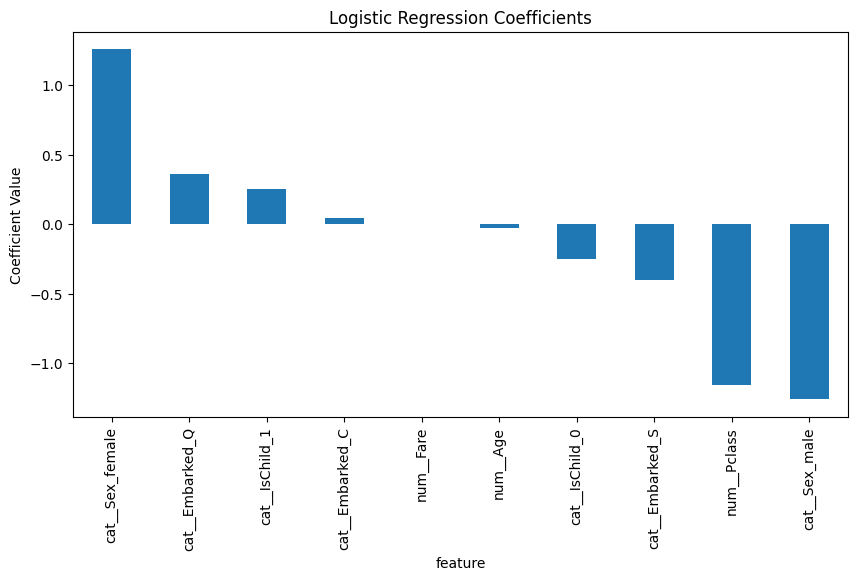

In [53]:
# Task D
coef_df.set_index("feature")["coefficient"].plot(kind="bar", figsize=(10, 5))
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

In [55]:
# Task E
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])
rf_model.fit(X_train, y_train)

rf_importances = rf_model.named_steps["model"].feature_importances_
rf_importances

rf_df = pd.DataFrame({
    "feature": features_names,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False)
rf_df

,feature,importance
2,num__Fare,0.298617
1,num__Age,0.259032
4,cat__Sex_male,0.147568
3,cat__Sex_female,0.140100
0,num__Pclass,0.100970
7,cat__Embarked_S,0.017035
5,cat__Embarked_C,0.011323
9,cat__IsChild_1,0.009770
8,cat__IsChild_0,0.009234
6,cat__Embarked_Q,0.006351


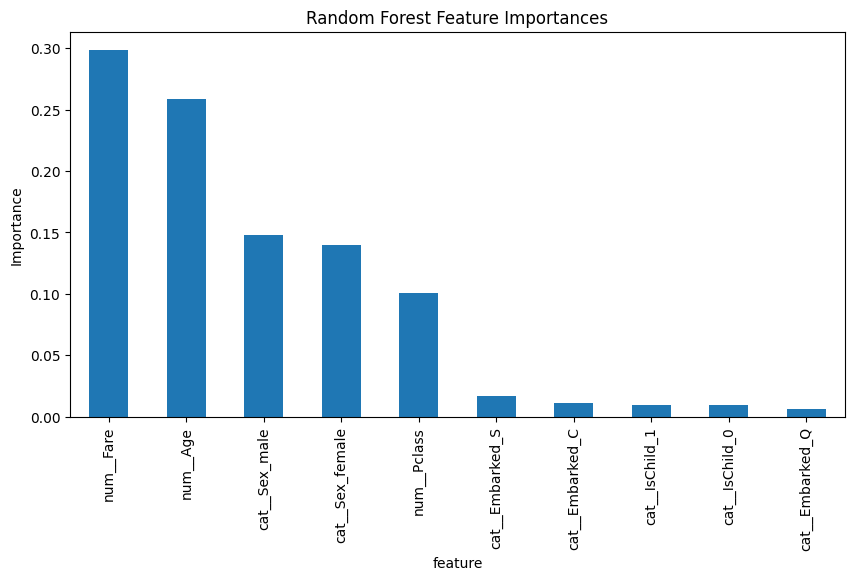

In [56]:
# Task F
rf_df.set_index("feature")["importance"].plot(kind="bar", figsize=(10, 5))
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.show()

## Выводы

- Logistic Regression позволяет интерпретировать признаки через коэффициенты
- Знак коэффициента показывает направление связи признака с целевым классом
- Random Forest даёт относительную важность признаков, но не направление влияния
- Для корректной интерпретации после pipeline нужно использовать итоговые имена признаков
- Важность признака не означает причинно-следственную связь